## XGBoost engineered-feature model

### 1. Import the libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_val_score
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 2. Define the project paths

In [2]:
PROJECT_ROOT = Path("..")

CLEANED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "crop_yield_cleaned.csv"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

TABLES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

MODELS_DIR = PROJECT_ROOT / "models"

# Create output folders if they do not exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Data path: {CLEANED_DATA_PATH.resolve()}")

Project root: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction
Data path: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction/data/processed/crop_yield_cleaned.csv


In [3]:
if not CLEANED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at: {CLEANED_DATA_PATH.resolve()}"
    )

print("Cleaned dataset found.")

Cleaned dataset found.


### 3. Load the cleaned dataset

In [4]:
data = pd.read_csv(CLEANED_DATA_PATH)

print(f"Dataset shape: {data.shape}")
display(data.head())

print("Column names:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes.to_frame("data_type"))

expected_columns = {
    "crop_type",
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "yield"
}

missing_columns = expected_columns.difference(data.columns)

if missing_columns:
    print("Missing expected columns:", missing_columns)
    print("Actual columns:", data.columns.tolist())
else:
    print("All expected columns are present.")

Dataset shape: (999, 8)


,rainfall,fertilizer,temperature,nitrogen,phosphorus,potassium,yield,crop_type
0,1230,80,28,80,24,20,12.0,Corn
1,480,60,36,70,20,18,8.0,Sorghum
2,1250,75,29,78,22,19,11.0,Soybean
3,450,65,35,70,19,18,9.0,Sorghum
4,1200,80,27,79,22,19,11.0,Wheat


Column names:
['rainfall', 'fertilizer', 'temperature', 'nitrogen', 'phosphorus', 'potassium', 'yield', 'crop_type']

Data types:


,data_type
rainfall,int64
fertilizer,int64
temperature,int64
nitrogen,int64
phosphorus,int64
potassium,int64
yield,float64
crop_type,str


All expected columns are present.


#### 4 Verify the cleaned data

In [5]:
data_checks = pd.DataFrame({
    "Check": [
        "Number of rows",
        "Number of columns",
        "Missing values",
        "Duplicate rows"
    ],
    "Value": [
        data.shape[0],
        data.shape[1],
        int(data.isna().sum().sum()),
        int(data.duplicated().sum())
    ]
})

display(data_checks)

,Check,Value
0,Number of rows,999
1,Number of columns,8
2,Missing values,0
3,Duplicate rows,0


### 5. Create the engineered features

In [6]:
# Make a copy so the cleaned dataset remains unchanged
xgb_data = data.copy()

# Create engineered features
xgb_data["total_npk"] = (
    xgb_data["nitrogen"]
    + xgb_data["phosphorus"]
    + xgb_data["potassium"]
)

# Confirm that total_npk does not contain zero
if (xgb_data["total_npk"] == 0).any():
    raise ValueError(
        "Some rows have total_npk equal to zero. "
        "The nutrient proportions cannot be calculated safely."
    )

xgb_data["n_proportion"] = (
    xgb_data["nitrogen"]
    / xgb_data["total_npk"]
)

xgb_data["p_proportion"] = (
    xgb_data["phosphorus"]
    / xgb_data["total_npk"]
)

xgb_data["temperature_squared"] = (
    xgb_data["temperature"] ** 2
)

xgb_data["rainfall_fertilizer_interaction"] = (
    xgb_data["rainfall"]
    * xgb_data["fertilizer"]
)

print(f"Shape after feature engineering: {xgb_data.shape}")

display(xgb_data.head())

Shape after feature engineering: (999, 13)


,rainfall,fertilizer,temperature,nitrogen,phosphorus,potassium,yield,crop_type,total_npk,n_proportion,p_proportion,temperature_squared,rainfall_fertilizer_interaction
0,1230,80,28,80,24,20,12.0,Corn,124,0.645161,0.193548,784,98400
1,480,60,36,70,20,18,8.0,Sorghum,108,0.648148,0.185185,1296,28800
2,1250,75,29,78,22,19,11.0,Soybean,119,0.655462,0.184874,841,93750
3,450,65,35,70,19,18,9.0,Sorghum,107,0.654206,0.177570,1225,29250
4,1200,80,27,79,22,19,11.0,Wheat,120,0.658333,0.183333,729,96000


### 6. Verify the engineered features

In [7]:
engineered_features = [
    "total_npk",
    "n_proportion",
    "p_proportion",
    "temperature_squared",
    "rainfall_fertilizer_interaction"
]

engineered_feature_checks = pd.DataFrame({
    "Feature": engineered_features,
    "Missing values": [
        xgb_data[feature].isna().sum()
        for feature in engineered_features
    ],
    "Infinite values": [
        np.isinf(xgb_data[feature]).sum()
        for feature in engineered_features
    ],
    "Minimum": [
        xgb_data[feature].min()
        for feature in engineered_features
    ],
    "Maximum": [
        xgb_data[feature].max()
        for feature in engineered_features
    ]
})

display(engineered_feature_checks.round(4))

,Feature,Missing values,Infinite values,Minimum,Maximum
0,total_npk,0,0,87.0000,139.0000
1,n_proportion,0,0,0.5391,0.7748
2,p_proportion,0,0,0.1200,0.2871
3,temperature_squared,0,0,400.0000,1600.0000
4,rainfall_fertilizer_interaction,0,0,20000.0000,136416.0000


In [8]:
assert xgb_data.shape == (999, 13), (
    f"Expected shape (999, 13), but obtained {xgb_data.shape}"
)

assert xgb_data[engineered_features].isna().sum().sum() == 0, (
    "The engineered features contain missing values."
)

assert np.isinf(
    xgb_data[engineered_features]
).sum().sum() == 0, (
    "The engineered features contain infinite values."
)

print("Engineered features verified successfully.")

Engineered features verified successfully.


### 7. Define the predictors and target

In [9]:
feature_columns = [
    "crop_type",
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "total_npk",
    "n_proportion",
    "p_proportion",
    "temperature_squared",
    "rainfall_fertilizer_interaction"
]

target_column = "yield"

X = xgb_data[feature_columns].copy()
y = xgb_data[target_column].copy()

print(f"Predictor shape: {X.shape}")
print(f"Target shape: {y.shape}")

display(X.head())
display(y.head())

Predictor shape: (999, 12)
Target shape: (999,)


,crop_type,rainfall,temperature,fertilizer,nitrogen,phosphorus,potassium,total_npk,n_proportion,p_proportion,temperature_squared,rainfall_fertilizer_interaction
0,Corn,1230,28,80,80,24,20,124,0.645161,0.193548,784,98400
1,Sorghum,480,36,60,70,20,18,108,0.648148,0.185185,1296,28800
2,Soybean,1250,29,75,78,22,19,119,0.655462,0.184874,841,93750
3,Sorghum,450,35,65,70,19,18,107,0.654206,0.177570,1225,29250
4,Wheat,1200,27,80,79,22,19,120,0.658333,0.183333,729,96000


0    12.0
1     8.0
2    11.0
3     9.0
4    11.0
Name: yield, dtype: float64

### 8. Create the training and test sets

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (799, 12)
X_test shape:  (200, 12)
y_train shape: (799,)
y_test shape:  (200,)


### 9. Define the preprocessing step

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = [
    "crop_type"
]

numeric_features = [
    "rainfall",
    "temperature",
    "fertilizer",
    "total_npk",
    "n_proportion",
    "p_proportion",
    "temperature_squared",
    "rainfall_fertilizer_interaction"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numeric_features
        )
    ],
    remainder="drop"
)

print("XGBoost preprocessing step created.")

XGBoost preprocessing step created.


### 10. Define the XGBoost pipeline

In [12]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
                eval_metric="rmse"
            )
        )
    ]
)

print("XGBoost pipeline created.")

XGBoost pipeline created.


### 11. Define the tuning grid

In [13]:
xgb_param_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],
    "model__max_depth": [
        3,
        5,
        7
    ],
    "model__learning_rate": [
        0.01,
        0.05,
        0.10
    ],
    "model__subsample": [
        0.7,
        1.0
    ],
    "model__colsample_bytree": [
        0.7,
        1.0
    ],
    "model__reg_lambda": [
        1,
        5
    ]
}

number_of_combinations = np.prod(
    [
        len(values)
        for values in xgb_param_grid.values()
    ]
)

print(
    "Number of hyperparameter combinations:",
    number_of_combinations
)

print(
    "Total five-fold model fits:",
    number_of_combinations * 5
)

Number of hyperparameter combinations: 216
Total five-fold model fits: 1080


### 12. Run five-fold GridSearchCV

In [14]:
from sklearn.model_selection import GridSearchCV, KFold

# Use reproducible five-fold cross-validation
kf5 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Prevent nested parallel processing
xgb_pipeline.set_params(
    model__n_jobs=1
)

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_grid.fit(
    X_train,
    y_train
)

print("Grid search completed.")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Grid search completed.


### 13. Display the best tuning result

In [15]:
best_parameters = xgb_grid.best_params_

best_cv_rmse = -xgb_grid.best_score_

print("Best hyperparameters:")

for parameter, value in best_parameters.items():
    clean_parameter = parameter.replace("model__", "")
    print(f"{clean_parameter}: {value}")

print(f"\nBest validation RMSE: {best_cv_rmse:.4f}")

Best hyperparameters:
colsample_bytree: 1.0
learning_rate: 0.01
max_depth: 3
n_estimators: 100
reg_lambda: 1
subsample: 1.0

Best validation RMSE: 2.7212


### 14. Extract the best XGBoost model

In [16]:
xgb_best = xgb_grid.best_estimator_

print("Best XGBoost pipeline:")
display(xgb_best)

Best XGBoost pipeline:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['crop_type','rainfall','temperature',...,'p_proportion', 'temperature_squared','rainfall_fertilizer_interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` wil

### 15. Save the tuning results

In [17]:
xgb_tuning_results = pd.DataFrame(
    xgb_grid.cv_results_
)

# Convert negative RMSE scores to positive RMSE
xgb_tuning_results["mean_validation_rmse"] = (
    -xgb_tuning_results["mean_test_score"]
)

xgb_tuning_results["std_validation_rmse"] = (
    xgb_tuning_results["std_test_score"]
)

# Arrange candidates from best to worst
xgb_tuning_results = xgb_tuning_results.sort_values(
    by="mean_validation_rmse",
    ascending=True
)

tuning_results_path = (
    TABLES_DIR
    / "xgboost_engineered_tuning_results.csv"
)

xgb_tuning_results.to_csv(
    tuning_results_path,
    index=False
)

print(f"Tuning results saved to: {tuning_results_path}")

Tuning results saved to: ../reports/tables/xgboost_engineered_tuning_results.csv


### 16. Display the five best combinations

In [18]:
parameter_columns = [
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__learning_rate",
    "param_model__subsample",
    "param_model__colsample_bytree",
    "param_model__reg_lambda",
    "mean_validation_rmse",
    "std_validation_rmse"
]

display(
    xgb_tuning_results[
        parameter_columns
    ].head().round(4)
)

,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__subsample,param_model__colsample_bytree,param_model__reg_lambda,mean_validation_rmse,std_validation_rmse
109,100,3,0.01,1.0,1.0,1,2.7212,0.0595
1,100,3,0.01,1.0,0.7,1,2.7221,0.0549
114,200,3,0.01,0.7,1.0,5,2.7222,0.0468
115,200,3,0.01,1.0,1.0,5,2.7223,0.0542
108,100,3,0.01,0.7,1.0,1,2.7228,0.0567


### 17. Generate predictions

In [19]:
# Generate predictions
xgb_train_pred = xgb_best.predict(X_train)
xgb_test_pred = xgb_best.predict(X_test)

print(f"Training predictions: {len(xgb_train_pred)}")
print(f"Test predictions: {len(xgb_test_pred)}")

Training predictions: 799
Test predictions: 200


### 18. Calculate training and test metrics

In [20]:
# Training metrics
xgb_train_mae = mean_absolute_error(
    y_train,
    xgb_train_pred
)

xgb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        xgb_train_pred
    )
)

xgb_train_r2 = r2_score(
    y_train,
    xgb_train_pred
)

# Test metrics
xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_pred
)

print(
    f"Train -> MAE: {xgb_train_mae:.4f} | "
    f"RMSE: {xgb_train_rmse:.4f} | "
    f"R²: {xgb_train_r2:.4f}"
)

print(
    f"Test  -> MAE: {xgb_test_mae:.4f} | "
    f"RMSE: {xgb_test_rmse:.4f} | "
    f"R²: {xgb_test_r2:.4f}"
)

Train -> MAE: 2.2411 | RMSE: 2.6322 | R²: 0.0957
Test  -> MAE: 2.5395 | RMSE: 2.9219 | R²: 0.0091


### 19. Save the performance results

In [21]:
xgb_performance_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Test"
    ],
    "MAE": [
        xgb_train_mae,
        xgb_test_mae
    ],
    "RMSE": [
        xgb_train_rmse,
        xgb_test_rmse
    ],
    "R_squared": [
        xgb_train_r2,
        xgb_test_r2
    ]
})

display(
    xgb_performance_results.round(4)
)

performance_path = (
    TABLES_DIR
    / "xgboost_engineered_performance.csv"
)

xgb_performance_results.to_csv(
    performance_path,
    index=False
)

print(f"Performance results saved to: {performance_path}")

,Dataset,MAE,RMSE,R_squared
0,Training,2.2411,2.6322,0.0957
1,Test,2.5395,2.9219,0.0091


Performance results saved to: ../reports/tables/xgboost_engineered_performance.csv


### 20. Five-fold cross-validation

In [22]:
from sklearn.model_selection import cross_val_score

xgb_cv_rmse = -cross_val_score(
    estimator=xgb_best,
    X=X,
    y=y,
    cv=kf5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("RMSE for each fold:")
print(np.round(xgb_cv_rmse, 4))

print(
    f"\nCV RMSE mean: {xgb_cv_rmse.mean():.4f}"
)

print(
    f"CV RMSE standard deviation: "
    f"{xgb_cv_rmse.std():.4f}"
)

RMSE for each fold:
[2.9219 2.8763 2.7426 2.718  2.5906]

CV RMSE mean: 2.7699
CV RMSE standard deviation: 0.1183


In [23]:
xgb_cv_results = pd.DataFrame({
    "Metric": [
        "CV RMSE Mean",
        "CV RMSE Standard Deviation"
    ],
    "Value": [
        xgb_cv_rmse.mean(),
        xgb_cv_rmse.std()
    ]
})

display(xgb_cv_results.round(4))

cv_results_path = (
    TABLES_DIR
    / "xgboost_engineered_cv_results.csv"
)

xgb_cv_results.to_csv(
    cv_results_path,
    index=False
)

print(f"CV results saved to: {cv_results_path}")

,Metric,Value
0,CV RMSE Mean,2.7699
1,CV RMSE Standard Deviation,0.1183


CV results saved to: ../reports/tables/xgboost_engineered_cv_results.csv


### 21. Plot actual versus predicted yield

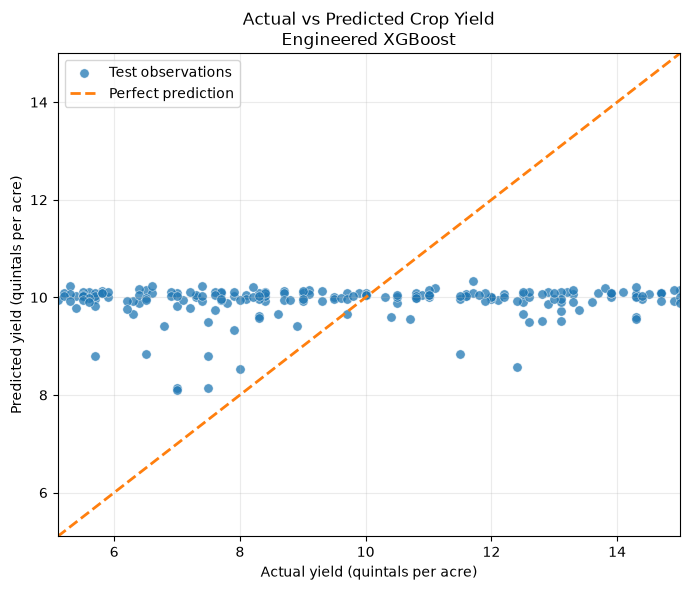

Figure saved to: ../reports/figures/xgboost_engineered_actual_vs_predicted.png


In [24]:
# Find common limits for both axes
minimum_value = min(
    float(y_test.min()),
    float(xgb_test_pred.min())
)

maximum_value = max(
    float(y_test.max()),
    float(xgb_test_pred.max())
)

fig, ax = plt.subplots(figsize=(7, 6))

# Actual-predicted pairs
ax.scatter(
    y_test,
    xgb_test_pred,
    color="#1F77B4",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.75,
    s=45,
    label="Test observations"
)

# Perfect-prediction reference line
ax.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="#FF7F0E",
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

ax.set_xlim(minimum_value, maximum_value)
ax.set_ylim(minimum_value, maximum_value)

ax.set_xlabel("Actual yield (quintals per acre)")
ax.set_ylabel("Predicted yield (quintals per acre)")

ax.set_title(
    "Actual vs Predicted Crop Yield\n"
    "Engineered XGBoost"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / "xgboost_engineered_actual_vs_predicted.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

### 22. Create the XGBoost results summary

In [25]:
xgb_results_summary = pd.DataFrame({
    "Model": [
        "XGBoost — Engineered Features"
    ],
    "Train MAE": [
        xgb_train_mae
    ],
    "Train RMSE": [
        xgb_train_rmse
    ],
    "Train R_squared": [
        xgb_train_r2
    ],
    "Test MAE": [
        xgb_test_mae
    ],
    "Test RMSE": [
        xgb_test_rmse
    ],
    "Test R_squared": [
        xgb_test_r2
    ],
    "CV RMSE Mean": [
        xgb_cv_rmse.mean()
    ],
    "CV RMSE Standard Deviation": [
        xgb_cv_rmse.std()
    ],
    "Best Tuning RMSE": [
        -xgb_grid.best_score_
    ]
})

display(
    xgb_results_summary.round(4)
)

,Model,Train MAE,Train RMSE,Train R_squared,Test MAE,Test RMSE,Test R_squared,CV RMSE Mean,CV RMSE Standard Deviation,Best Tuning RMSE
0,XGBoost — Engineered Features,2.2411,2.6322,0.0957,2.5395,2.9219,0.0091,2.7699,0.1183,2.7212


In [26]:
summary_path = (
    TABLES_DIR
    / "xgboost_engineered_results_summary.csv"
)

xgb_results_summary.to_csv(
    summary_path,
    index=False
)

print(f"Results summary saved to: {summary_path}")

Results summary saved to: ../reports/tables/xgboost_engineered_results_summary.csv


### 23. Display the selected hyperparameters clearly

In [27]:
print("Selected XGBoost hyperparameters:\n")

for parameter, value in xgb_grid.best_params_.items():
    parameter_name = parameter.replace(
        "model__",
        ""
    )

    print(f"{parameter_name}: {value}")

Selected XGBoost hyperparameters:

colsample_bytree: 1.0
learning_rate: 0.01
max_depth: 3
n_estimators: 100
reg_lambda: 1
subsample: 1.0
